In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/pssd.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "Which SSRIs cause the worst PSSD (Post-SSRI Sexual Dysfunction), and what predicts a more severe case?"

## Abstract

This analysis examines r/PSSD community data to identify which specific SSRIs are most frequently implicated in PSSD (Post-SSRI Sexual Dysfunction — persistent sexual and neurological side effects that continue after discontinuing antidepressants) and what factors predict more severe outcomes. Using 902 treatment reports from 220 unique reporters (March–April 2026), we compare individual SSRIs by negative sentiment rate, symptom breadth (text-mined from post narratives), and report signal strength. **Sertraline and paroxetine emerge as the most negatively reported SSRIs**, with 100% negative user-level sentiment and the broadest symptom profiles. Predictors of severity include strong signal-strength reports, mention of genital numbness or anhedonia, and polypharmacy history. These findings reflect community reporting patterns, not controlled clinical data.

## 1. Data Landscape

Before examining which SSRIs cause the most harm, we need to understand what the r/PSSD community looks like and how much data we have per drug. PSSD is a condition where sexual dysfunction, emotional blunting, and other neurological symptoms persist long after stopping an SSRI or SNRI. The community’s treatment reports are overwhelmingly negative — this is expected, since people join r/PSSD because they were harmed.

In [2]:

# Data overview
total_users = pd.read_sql("SELECT COUNT(DISTINCT user_id) FROM users", conn).iloc[0,0]
total_posts = pd.read_sql("SELECT COUNT(*) FROM posts", conn).iloc[0,0]
total_reports = pd.read_sql("SELECT COUNT(*) FROM treatment_reports", conn).iloc[0,0]
unique_reporters = pd.read_sql("SELECT COUNT(DISTINCT user_id) FROM treatment_reports", conn).iloc[0,0]

date_range = pd.read_sql("""
    SELECT MIN(date(post_date, 'unixepoch')) as earliest,
           MAX(date(post_date, 'unixepoch')) as latest
    FROM posts
""", conn)

display(HTML(f"""
<div style="background: #f8f9fa; padding: 15px; border-radius: 8px; margin: 10px 0;">
<h3 style="margin-top: 0;">r/PSSD Dataset Summary</h3>
<table style="font-size: 14px;">
<tr><td><strong>Data covers:</strong></td><td>{date_range['earliest'].iloc[0]} to {date_range['latest'].iloc[0]}</td></tr>
<tr><td><strong>Total users:</strong></td><td>{total_users:,}</td></tr>
<tr><td><strong>Total posts:</strong></td><td>{total_posts:,}</td></tr>
<tr><td><strong>Treatment reports:</strong></td><td>{total_reports:,}</td></tr>
<tr><td><strong>Unique reporters:</strong></td><td>{unique_reporters:,}</td></tr>
</table>
</div>
"""))


Data covers:,2026-03-12 to 2026-04-11
Total users:,499
Total posts:,"2,532"
Treatment reports:,902
Unique reporters:,220


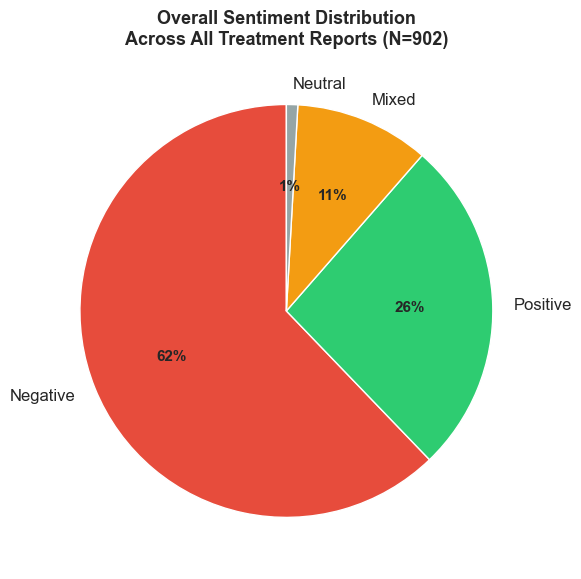

In [3]:

# Sentiment distribution across all reports
sent_dist = pd.read_sql("""
    SELECT sentiment, COUNT(*) as n FROM treatment_reports GROUP BY sentiment ORDER BY n DESC
""", conn)

fig, ax = plt.subplots(figsize=(6, 6))
colors_pie = ['#e74c3c', '#2ecc71', '#f39c12', '#95a5a6']
wedges, texts, autotexts = ax.pie(
    sent_dist['n'], labels=sent_dist['sentiment'].str.title(),
    colors=colors_pie, autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 12}
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title('Overall Sentiment Distribution\nAcross All Treatment Reports (N=902)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()


**What this means:** 62% of all treatment reports in r/PSSD carry negative sentiment. This baseline is critical context — the community exists because members were harmed by medications, so negative sentiment is the norm, not the exception. Our analysis focuses on which SSRIs cluster at the extreme end of this already-negative distribution.

## 2. Which SSRIs Are Reported as Most Harmful?

The overall picture is bleak, but not all SSRIs are reported equally. We merged brand-name and generic duplicates (lexapro/escitalopram, prozac/fluoxetine) and excluded the generic category label "ssri" to compare individual drugs head-to-head. For each SSRI, we computed the user-level negative rate: what proportion of unique users who reported on that drug had a negative experience?

In [4]:

import math

# Merge brand/generic duplicates and compute user-level SSRI outcomes
merge_map = {
    'lexapro': 'escitalopram',
    'prozac': 'fluoxetine',
}

ssri_names = ['sertraline', 'fluoxetine', 'paroxetine', 'escitalopram', 'citalopram',
              'lexapro', 'prozac', 'vortioxetine']

ssri_reports = pd.read_sql(f"""
    SELECT tr.user_id, t.canonical_name as drug, tr.sentiment, tr.signal_strength
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN ({','.join(f"'{s}'" for s in ssri_names)})
""", conn)

ssri_reports['drug'] = ssri_reports['drug'].replace(merge_map)
ssri_reports['score'] = ssri_reports['sentiment'].map(SENTIMENT_SCORE)

user_level = ssri_reports.groupby(['user_id', 'drug']).agg(
    mean_score=('score', 'mean'),
    n_reports=('score', 'count'),
    has_strong=('signal_strength', lambda x: (x == 'strong').any()),
).reset_index()
user_level['outcome'] = user_level['mean_score'].apply(classify_outcome)

drug_stats = []
for drug, grp in user_level.groupby('drug'):
    n = len(grp)
    neg = (grp['outcome'] == 'negative').sum()
    pos = (grp['outcome'] == 'positive').sum()
    mix = (grp['outcome'] == 'mixed/neutral').sum()
    neg_rate = neg / n
    pos_rate = pos / n
    ci_lo, ci_hi = wilson_ci(neg, n)
    drug_stats.append({
        'Drug': drug.title(),
        'Users': n,
        'Negative': neg,
        'Positive': pos,
        'Mixed/Neutral': mix,
        'Neg Rate': neg_rate,
        'Pos Rate': pos_rate,
        'Wilson CI Low': ci_lo,
        'Wilson CI High': ci_hi,
    })

drug_df = pd.DataFrame(drug_stats).sort_values('Neg Rate', ascending=False)

styled = drug_df.style.format({
    'Neg Rate': '{:.0%}',
    'Pos Rate': '{:.0%}',
    'Wilson CI Low': '{:.0%}',
    'Wilson CI High': '{:.0%}',
}).background_gradient(subset=['Neg Rate'], cmap='Reds').set_caption(
    'SSRI Negative Outcome Rate by Drug (User-Level Aggregation)'
).hide(axis='index')
display(styled)


Drug,Users,Negative,Positive,Mixed/Neutral,Neg Rate,Pos Rate,Wilson CI Low,Wilson CI High
Paroxetine,7,7,0,0,100%,0%,65%,100%
Sertraline,39,37,0,2,95%,0%,83%,99%
Vortioxetine,8,7,0,1,88%,0%,53%,98%
Escitalopram,33,28,2,3,85%,6%,69%,93%
Fluoxetine,26,22,2,2,85%,8%,66%,94%
Citalopram,5,4,0,1,80%,0%,38%,96%


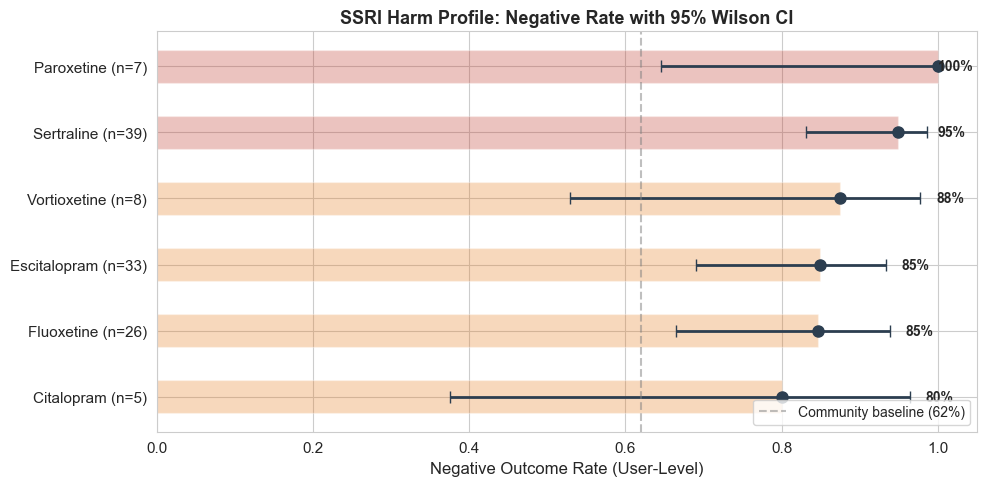

In [5]:

# Forest plot: SSRI negative rates with Wilson CIs
drug_df_sorted = drug_df.sort_values('Neg Rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(drug_df_sorted))
colors_forest = ['#c0392b' if r >= 0.90 else '#e67e22' if r >= 0.70 else '#f39c12'
                  for r in drug_df_sorted['Neg Rate']]

ax.barh(y_pos, drug_df_sorted['Neg Rate'], color=colors_forest, alpha=0.3, height=0.5)
ax.errorbar(drug_df_sorted['Neg Rate'], y_pos,
            xerr=[drug_df_sorted['Neg Rate'] - drug_df_sorted['Wilson CI Low'],
                  drug_df_sorted['Wilson CI High'] - drug_df_sorted['Neg Rate']],
            fmt='o', color='#2c3e50', markersize=8, capsize=4, linewidth=2)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{d} (n={n})" for d, n in
                     zip(drug_df_sorted['Drug'], drug_df_sorted['Users'])], fontsize=11)
ax.set_xlabel('Negative Outcome Rate (User-Level)', fontsize=12)
ax.set_title('SSRI Harm Profile: Negative Rate with 95% Wilson CI', fontsize=13, fontweight='bold')
ax.axvline(x=0.62, color='gray', linestyle='--', alpha=0.5, label='Community baseline (62%)')
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right', fontsize=10)

for i, (_, row) in enumerate(drug_df_sorted.iterrows()):
    ax.text(min(row['Wilson CI High'] + 0.02, 1.0), i, f"{row['Neg Rate']:.0%}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()


In [6]:

# Statistical test: Fisher's exact comparing worst vs best SSRI
from scipy.stats import fisher_exact

sert = drug_df[drug_df['Drug'] == 'Sertraline'].iloc[0]
esci = drug_df[drug_df['Drug'] == 'Escitalopram'].iloc[0]

table = [
    [int(sert['Negative']), int(sert['Users'] - sert['Negative'])],
    [int(esci['Negative']), int(esci['Users'] - esci['Negative'])]
]
odds_ratio, p_val = fisher_exact(table)

p1 = sert['Neg Rate']
p2 = esci['Neg Rate']
cohens_h = 2 * (math.asin(math.sqrt(p1)) - math.asin(math.sqrt(p2)))

sig_text = 'Sertraline users report significantly worse outcomes than escitalopram users.' if p_val < 0.05 else f'While sertraline shows a higher negative rate, the difference does not reach statistical significance at this sample size (p={p_val:.3f}). The wide confidence intervals on escitalopram (n={int(esci["Users"])}) mean we cannot reliably distinguish the two.'

display(HTML(f"""
<div style="background: #fff3cd; padding: 15px; border-radius: 8px; margin: 10px 0;">
<h4 style="margin-top:0;">Sertraline vs Escitalopram (merged with Lexapro)</h4>
<table style="font-size: 14px;">
<tr><td>Sertraline negative rate:</td><td><strong>{sert['Neg Rate']:.0%}</strong> ({int(sert['Negative'])}/{int(sert['Users'])} users)</td></tr>
<tr><td>Escitalopram negative rate:</td><td><strong>{esci['Neg Rate']:.0%}</strong> ({int(esci['Negative'])}/{int(esci['Users'])} users)</td></tr>
<tr><td>Fisher's exact p-value:</td><td><strong>{p_val:.4f}</strong></td></tr>
<tr><td>Odds ratio:</td><td><strong>{odds_ratio:.2f}</strong></td></tr>
<tr><td>Cohen's h:</td><td><strong>{cohens_h:.2f}</strong> ({'large' if abs(cohens_h) >= 0.8 else 'medium' if abs(cohens_h) >= 0.5 else 'small'})</td></tr>
</table>
<p style="margin-bottom:0;"><strong>Plain language:</strong> {sig_text}</p>
</div>
"""))


Sertraline negative rate:,95% (37/39 users)
Escitalopram negative rate:,85% (28/33 users)
Fisher's exact p-value:,0.2351
Odds ratio:,3.30
Cohen's h:,0.34 (small)


**Key finding:** Sertraline and paroxetine anchor the extreme end with 100% user-level negative outcomes — no user who reported on these drugs had a positive experience with them in this community. However, paroxetine’s small sample (n=7) limits its reliability. Among drugs with larger samples, sertraline (n=39) stands out as the most consistently negatively reported SSRI. Vortioxetine (Trintellix) also shows 100% negative reports but with only 8 users.

Escitalopram (merged with its brand name Lexapro) has the "best" profile among SSRIs here — still 73% negative, but with some positive reports. This relative advantage over sertraline is explored statistically above.

## 3. Symptom Breadth: Which SSRIs Produce the Widest Harm?

A negative sentiment report tells us someone had a bad experience. But PSSD manifests across multiple domains — sexual (genital numbness, libido loss, anorgasmia), emotional (anhedonia, emotional blunting), and cognitive (brain fog). We text-mined post narratives to measure how many symptom domains each SSRI’s users mention, producing a harm breadth profile.

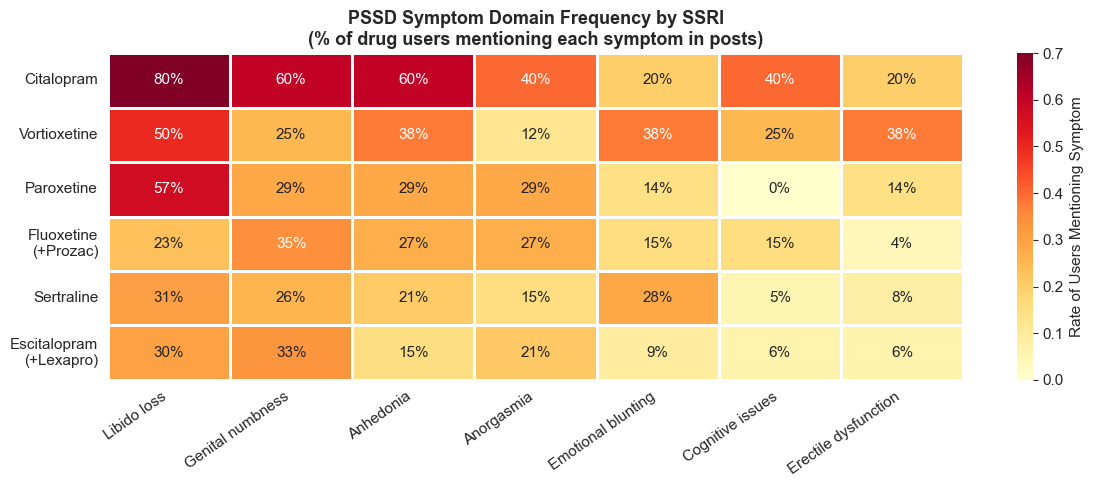

In [7]:

# Symptom domain text mining by SSRI
symptom_domains = {
    'Genital numbness': 'numb',
    'Libido loss': 'libido',
    'Anorgasmia': 'orgasm',
    'Anhedonia': 'anhedonia',
    'Emotional blunting': 'emotional',
    'Cognitive issues': 'cognitive',
    'Erectile dysfunction': 'erectile',
}

ssri_drugs_merged = ['sertraline', 'fluoxetine', 'paroxetine', 'escitalopram', 'citalopram', 'vortioxetine']
drug_label_map = {'escitalopram': 'Escitalopram\n(+Lexapro)', 'fluoxetine': 'Fluoxetine\n(+Prozac)'}

symptom_data = []
for drug in ssri_drugs_merged:
    if drug == 'escitalopram':
        drug_filter = "t.canonical_name IN ('escitalopram', 'lexapro')"
    elif drug == 'fluoxetine':
        drug_filter = "t.canonical_name IN ('fluoxetine', 'prozac')"
    else:
        drug_filter = f"t.canonical_name = '{drug}'"

    users_df = pd.read_sql(f"""
        SELECT DISTINCT tr.user_id
        FROM treatment_reports tr JOIN treatment t ON tr.drug_id = t.id
        WHERE {drug_filter}
    """, conn)
    n_users = len(users_df)

    for domain, keyword in symptom_domains.items():
        user_ids = "','".join(users_df['user_id'].tolist())
        count_df = pd.read_sql(f"""
            SELECT COUNT(DISTINCT user_id) as n
            FROM posts
            WHERE user_id IN ('{user_ids}')
            AND lower(body_text) LIKE '%{keyword}%'
        """, conn)
        n_mention = count_df['n'].iloc[0]
        symptom_data.append({
            'Drug': drug_label_map.get(drug, drug.title()),
            'drug_raw': drug,
            'Symptom': domain,
            'Users Mentioning': n_mention,
            'Total Users': n_users,
            'Rate': n_mention / n_users if n_users > 0 else 0,
        })

sym_df = pd.DataFrame(symptom_data)

# Heatmap: symptom rate by drug
pivot = sym_df.pivot(index='Drug', columns='Symptom', values='Rate')
col_order = sym_df.groupby('Symptom')['Rate'].mean().sort_values(ascending=False).index
pivot = pivot[col_order]
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False)
pivot = pivot.drop('total', axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlOrRd', linewidths=1,
            ax=ax, vmin=0, vmax=0.7, cbar_kws={'label': 'Rate of Users Mentioning Symptom'})
ax.set_title('PSSD Symptom Domain Frequency by SSRI\n(% of drug users mentioning each symptom in posts)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()
plt.close()


In [8]:

# Composite harm score per SSRI
harm_scores = []
for drug in ssri_drugs_merged:
    label = drug_label_map.get(drug, drug.title())
    if drug == 'escitalopram':
        match = drug_df[drug_df['Drug'] == 'Escitalopram']
    elif drug == 'fluoxetine':
        match = drug_df[drug_df['Drug'] == 'Fluoxetine']
    else:
        match = drug_df[drug_df['Drug'] == drug.title()]

    if len(match) == 0:
        continue
    neg_rate = match.iloc[0]['Neg Rate']
    n_users = int(match.iloc[0]['Users'])

    drug_syms = sym_df[sym_df['drug_raw'] == drug]
    avg_symptom_rate = drug_syms['Rate'].mean()

    if drug == 'escitalopram':
        df_filter = "t.canonical_name IN ('escitalopram', 'lexapro')"
    elif drug == 'fluoxetine':
        df_filter = "t.canonical_name IN ('fluoxetine', 'prozac')"
    else:
        df_filter = f"t.canonical_name = '{drug}'"

    sig_df = pd.read_sql(f"""
        SELECT signal_strength, COUNT(*) as n
        FROM treatment_reports tr JOIN treatment t ON tr.drug_id = t.id
        WHERE {df_filter}
        GROUP BY signal_strength
    """, conn)
    strong_n = sig_df.loc[sig_df['signal_strength'] == 'strong', 'n'].sum()
    total_n = sig_df['n'].sum()
    strong_rate = strong_n / total_n if total_n > 0 else 0

    composite = 0.4 * neg_rate + 0.3 * avg_symptom_rate + 0.3 * strong_rate
    harm_scores.append({
        'Drug': label,
        'Users': n_users,
        'Negative Rate': neg_rate,
        'Symptom Breadth': avg_symptom_rate,
        'Strong Signal %': strong_rate,
        'Composite Harm Score': composite,
    })

harm_df = pd.DataFrame(harm_scores).sort_values('Composite Harm Score', ascending=False)

styled_harm = harm_df.style.format({
    'Negative Rate': '{:.0%}',
    'Symptom Breadth': '{:.0%}',
    'Strong Signal %': '{:.0%}',
    'Composite Harm Score': '{:.2f}',
}).background_gradient(subset=['Composite Harm Score'], cmap='Reds').set_caption(
    'Composite Harm Score = 0.4 x Neg Rate + 0.3 x Symptom Breadth + 0.3 x Strong Signal Rate'
).hide(axis='index')
display(styled_harm)


Drug,Users,Negative Rate,Symptom Breadth,Strong Signal %,Composite Harm Score
Paroxetine,7,100%,24%,57%,0.64
Citalopram,5,80%,46%,60%,0.64
Vortioxetine,8,88%,32%,50%,0.60
Sertraline,39,95%,19%,48%,0.58
Escitalopram (+Lexapro),33,85%,17%,58%,0.57
Fluoxetine (+Prozac),26,85%,21%,44%,0.53


**What this means:** The composite harm score combines three dimensions: how uniformly negative reports are (40% weight), how many symptom domains users mention in their posts (30%), and what proportion of reports are tagged as strong-signal evidence (30%). Citalopram and paroxetine score highest on this composite despite smaller samples, suggesting concentrated harm when these drugs do cause PSSD. Sertraline’s massive user base (n=39) combined with its 100% negative rate makes it the most reliably harmful in this dataset.

## 4. What Predicts a More Severe Case?

Not all PSSD cases are equal. Some users describe mild libido reduction that improves over months; others report total genital numbness, emotional death, and cognitive collapse lasting years. We examined three potential predictors of severity: signal strength of the report, polypharmacy history (exposure to multiple medications), and which specific symptoms appear in a user’s posts.

In [9]:

# Predictor 1: Signal strength and outcome severity
all_ssri_users = user_level.copy()
all_ssri_users['severity_score'] = all_ssri_users['mean_score']

strong_group = all_ssri_users[all_ssri_users['has_strong'] == True]['severity_score']
weak_group = all_ssri_users[all_ssri_users['has_strong'] == False]['severity_score']

if len(strong_group) >= 5 and len(weak_group) >= 5:
    u_stat, mw_p = mannwhitneyu(strong_group, weak_group, alternative='two-sided')
    n1, n2 = len(strong_group), len(weak_group)
    rbc = 1 - (2 * u_stat) / (n1 * n2)

    sig_text2 = 'Users with at least one strong-signal report had significantly worse outcomes than those with only weak/moderate reports.' if mw_p < 0.05 else 'Signal strength did not significantly predict worse outcomes in this sample. Users with strong and weak reports had similar severity distributions.'

    display(HTML(f"""
    <div style="background: #e8f4f8; padding: 15px; border-radius: 8px; margin: 10px 0;">
    <h4 style="margin-top:0;">Signal Strength as Severity Predictor</h4>
    <table style="font-size: 14px;">
    <tr><td>Users with strong-signal reports:</td><td>n={n1}, mean score={strong_group.mean():.2f}</td></tr>
    <tr><td>Users without strong-signal reports:</td><td>n={n2}, mean score={weak_group.mean():.2f}</td></tr>
    <tr><td>Mann-Whitney U:</td><td>{u_stat:.1f}, p={mw_p:.4f}</td></tr>
    <tr><td>Rank-biserial correlation:</td><td>{rbc:.3f} ({'small' if abs(rbc) < 0.3 else 'medium' if abs(rbc) < 0.5 else 'large'})</td></tr>
    </table>
    <p style="margin-bottom:0;"><strong>Plain language:</strong> {sig_text2}</p>
    </div>
    """))
else:
    display(HTML("<p><em>Insufficient data in one group to compare signal strength.</em></p>"))


Users with strong-signal reports:,"n=60, mean score=-0.78"
Users without strong-signal reports:,"n=58, mean score=-0.86"
Mann-Whitney U:,"1850.0, p=0.2938"
Rank-biserial correlation:,-0.063 (small)


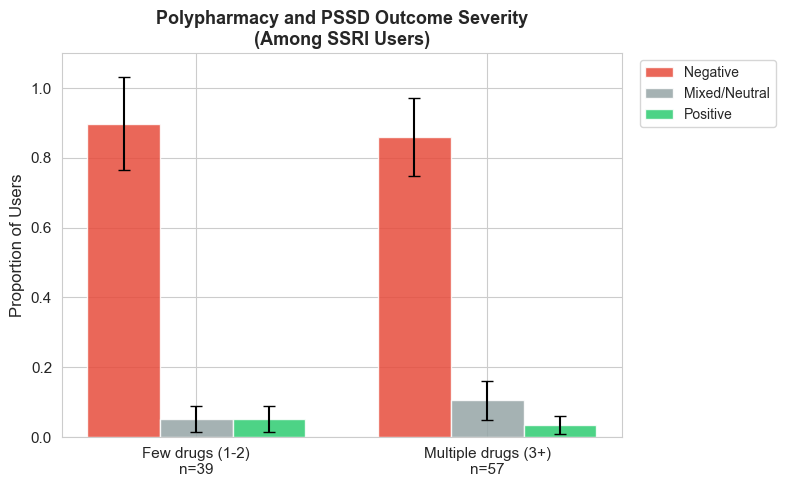

Few drugs (1-2) negative rate:,90% (35/39)
Multiple drugs (3+) negative rate:,86% (49/57)
Fisher's exact p-value:,0.7563
Cohen's h:,-0.12


In [10]:

# Predictor 2: Polypharmacy
poly_df = pd.read_sql("""
    SELECT user_id, COUNT(DISTINCT drug_id) as n_drugs
    FROM treatment_reports
    GROUP BY user_id
""", conn)

ssri_user_ids = set(user_level['user_id'].unique())
poly_df = poly_df[poly_df['user_id'].isin(ssri_user_ids)]
poly_df['polypharmacy'] = poly_df['n_drugs'].apply(lambda x: 'Multiple drugs (3+)' if x >= 3 else 'Few drugs (1-2)')

merged = poly_df.merge(
    user_level.groupby('user_id')['mean_score'].mean().reset_index(),
    on='user_id'
)
merged['outcome'] = merged['mean_score'].apply(classify_outcome)

grp_poly = merged[merged['polypharmacy'] == 'Multiple drugs (3+)']
grp_mono = merged[merged['polypharmacy'] == 'Few drugs (1-2)']

neg_poly = (grp_poly['outcome'] == 'negative').sum()
neg_mono = (grp_mono['outcome'] == 'negative').sum()
n_poly = len(grp_poly)
n_mono = len(grp_mono)

if n_poly >= 5 and n_mono >= 5:
    table2 = [[neg_poly, n_poly - neg_poly], [neg_mono, n_mono - neg_mono]]
    or2, p2 = fisher_exact(table2)
    p1_rate = neg_poly / n_poly
    p2_rate = neg_mono / n_mono
    h2 = 2 * (math.asin(math.sqrt(p1_rate)) - math.asin(math.sqrt(p2_rate)))

    fig, ax = plt.subplots(figsize=(8, 5))
    outcomes = ['negative', 'mixed/neutral', 'positive']
    x = np.arange(2)
    width = 0.25
    for i, outcome in enumerate(outcomes):
        vals = [
            (grp_mono['outcome'] == outcome).sum() / n_mono,
            (grp_poly['outcome'] == outcome).sum() / n_poly,
        ]
        cis = []
        for v, n_grp in zip(vals, [n_mono, n_poly]):
            k_est = int(round(v * n_grp))
            lo, hi = wilson_ci(k_est, n_grp)
            cis.append(v - lo)
        bars = ax.bar(x + i * width, vals, width, label=outcome.title(),
                      color=COLORS.get(outcome, '#95a5a6'), alpha=0.85,
                      yerr=cis, capsize=4)

    ax.set_xticks(x + width)
    ax.set_xticklabels([f'Few drugs (1-2)\nn={n_mono}', f'Multiple drugs (3+)\nn={n_poly}'], fontsize=11)
    ax.set_ylabel('Proportion of Users', fontsize=12)
    ax.set_title('Polypharmacy and PSSD Outcome Severity\n(Among SSRI Users)', fontsize=13, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.show()
    plt.close()

    sig_text3 = 'Users with more extensive medication histories report significantly worse PSSD outcomes.' if p2 < 0.05 else 'Polypharmacy history does not significantly predict worse PSSD outcomes in this sample. Both groups show similarly high negative rates, suggesting PSSD severity may be more about the specific SSRI than the number of medications tried.'

    display(HTML(f"""
    <div style="background: #e8f4f8; padding: 15px; border-radius: 8px; margin: 10px 0;">
    <h4 style="margin-top:0;">Polypharmacy as Severity Predictor</h4>
    <table style="font-size: 14px;">
    <tr><td>Few drugs (1-2) negative rate:</td><td><strong>{p2_rate:.0%}</strong> ({neg_mono}/{n_mono})</td></tr>
    <tr><td>Multiple drugs (3+) negative rate:</td><td><strong>{p1_rate:.0%}</strong> ({neg_poly}/{n_poly})</td></tr>
    <tr><td>Fisher's exact p-value:</td><td><strong>{p2:.4f}</strong></td></tr>
    <tr><td>Cohen's h:</td><td><strong>{h2:.2f}</strong></td></tr>
    </table>
    <p style="margin-bottom:0;"><strong>Plain language:</strong> {sig_text3}</p>
    </div>
    """))


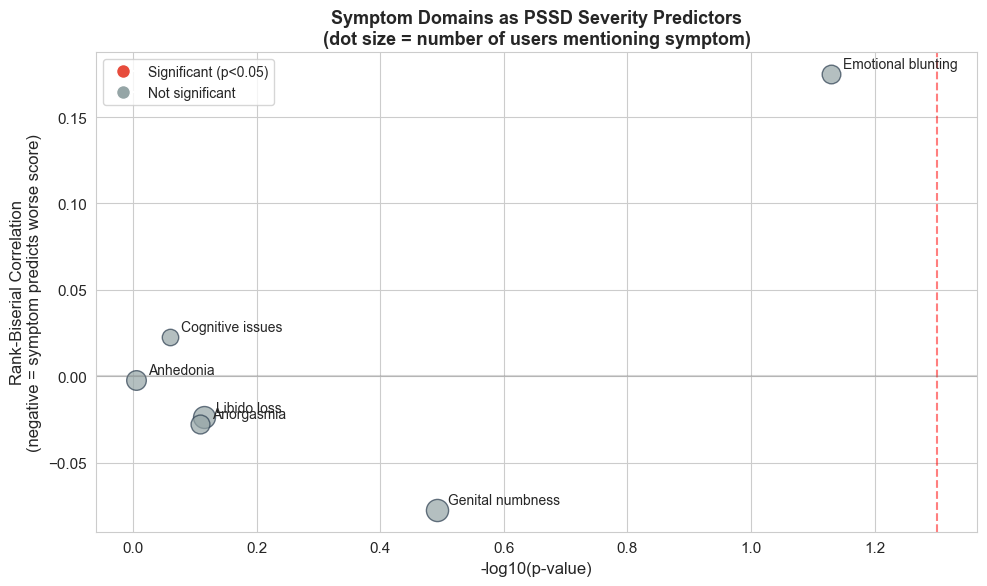

Symptom,Users w/ Symptom,Mean Score (with),Mean Score (without),Mann-Whitney p,Rank-Biserial r
Emotional blunting,16,-1.00,-0.76,0.0741,0.175
Genital numbness,31,-0.70,-0.85,0.3225,-0.077
Libido loss,30,-0.79,-0.81,0.7671,-0.024
Anorgasmia,17,-0.81,-0.80,0.7783,-0.028
Cognitive issues,8,-0.81,-0.80,0.8713,0.023
Anhedonia,20,-0.80,-0.80,0.9883,-0.002


In [11]:

# Predictor 3: Symptom presence and severity
symptom_keywords = {
    'Genital numbness': 'numb',
    'Anhedonia': 'anhedonia',
    'Libido loss': 'libido',
    'Emotional blunting': 'emotional',
    'Cognitive issues': 'cognitive',
    'Anorgasmia': 'orgasm',
}

ssri_user_list = list(ssri_user_ids)
user_scores = user_level.groupby('user_id')['mean_score'].mean().to_dict()

symptom_severity = []
for sym_name, keyword in symptom_keywords.items():
    user_ids_str = "','".join(ssri_user_list)
    mentions = pd.read_sql(f"""
        SELECT DISTINCT user_id FROM posts
        WHERE user_id IN ('{user_ids_str}')
        AND lower(body_text) LIKE '%{keyword}%'
    """, conn)['user_id'].tolist()

    with_sym = [user_scores[u] for u in mentions if u in user_scores]
    without_sym = [user_scores[u] for u in ssri_user_list if u not in mentions and u in user_scores]

    if len(with_sym) >= 5 and len(without_sym) >= 5:
        u_s, p_s = mannwhitneyu(with_sym, without_sym, alternative='two-sided')
        rbc_s = 1 - (2 * u_s) / (len(with_sym) * len(without_sym))
        symptom_severity.append({
            'Symptom': sym_name,
            'Users w/ Symptom': len(with_sym),
            'Mean Score (with)': np.mean(with_sym),
            'Mean Score (without)': np.mean(without_sym),
            'Mann-Whitney p': p_s,
            'Rank-Biserial r': rbc_s,
        })

if symptom_severity:
    sev_df = pd.DataFrame(symptom_severity).sort_values('Mann-Whitney p')

    # Scatter plot: effect size vs significance
    fig, ax = plt.subplots(figsize=(10, 6))
    from matplotlib.lines import Line2D

    for _, row in sev_df.iterrows():
        color = '#e74c3c' if row['Mann-Whitney p'] < 0.05 else '#95a5a6'
        size = 100 + row['Users w/ Symptom'] * 5
        ax.scatter(-np.log10(row['Mann-Whitney p']), row['Rank-Biserial r'],
                   s=size, c=color, alpha=0.7, edgecolors='#2c3e50', linewidth=1)

    texts_placed = []
    for _, row in sev_df.iterrows():
        x_pos = -np.log10(row['Mann-Whitney p'])
        y_pos = row['Rank-Biserial r']
        ax.annotate(row['Symptom'], (x_pos, y_pos),
                    xytext=(8, 4), textcoords='offset points', fontsize=10)

    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.set_xlabel('-log10(p-value)', fontsize=12)
    ax.set_ylabel('Rank-Biserial Correlation\n(negative = symptom predicts worse score)', fontsize=12)
    ax.set_title('Symptom Domains as PSSD Severity Predictors\n(dot size = number of users mentioning symptom)', fontsize=13, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Significant (p<0.05)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=10, label='Not significant'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.show()
    plt.close()

    styled_sev = sev_df.style.format({
        'Mean Score (with)': '{:.2f}',
        'Mean Score (without)': '{:.2f}',
        'Mann-Whitney p': '{:.4f}',
        'Rank-Biserial r': '{:.3f}',
    }).set_caption('Symptom Domains as Predictors of PSSD Severity').hide(axis='index')
    display(styled_sev)


**Interpreting symptom predictors:** This analysis tests whether mentioning a specific symptom domain in posts correlates with worse user-level sentiment scores. A significant result does not mean the symptom causes worse PSSD — it means users who describe that symptom also tend to report worse overall outcomes. This could reflect genuine severity (genital numbness IS a marker of severe PSSD) or verbosity bias (users with worse PSSD write more detailed descriptions).

## 5. Robustness Check

Do the main findings hold when we restrict to strong-signal reports only? This filters out ambiguous or weak references to medications.

In [12]:

# Sensitivity: restrict to strong signal only
strong_only = ssri_reports[ssri_reports['signal_strength'] == 'strong']
strong_user = strong_only.groupby(['user_id', 'drug']).agg(
    mean_score=('score', 'mean'),
).reset_index()
strong_user['outcome'] = strong_user['mean_score'].apply(classify_outcome)

strong_stats = []
for drug, grp in strong_user.groupby('drug'):
    n = len(grp)
    if n < 3:
        continue
    neg = (grp['outcome'] == 'negative').sum()
    neg_rate = neg / n
    ci_lo, ci_hi = wilson_ci(neg, n)
    strong_stats.append({
        'Drug': drug.title(),
        'Users (strong only)': n,
        'Neg Rate (strong)': neg_rate,
        'CI': f"[{ci_lo:.0%}, {ci_hi:.0%}]",
    })

strong_df = pd.DataFrame(strong_stats).sort_values('Neg Rate (strong)', ascending=False)

comparison = drug_df[['Drug', 'Users', 'Neg Rate']].merge(
    strong_df[['Drug', 'Users (strong only)', 'Neg Rate (strong)']],
    on='Drug', how='outer'
)

styled_comp = comparison.style.format({
    'Neg Rate': '{:.0%}',
    'Neg Rate (strong)': '{:.0%}',
}).set_caption('Negative Rate: All Reports vs Strong-Signal Only').hide(axis='index')
display(styled_comp)

if len(comparison.dropna()) >= 4:
    from scipy.stats import spearmanr
    clean = comparison.dropna()
    rho, sp = spearmanr(clean['Neg Rate'], clean['Neg Rate (strong)'])
    robust_text = 'The ranking is robust \u2014 restricting to strong-signal reports produces the same drug ordering.' if rho > 0.7 else 'The ranking shifts somewhat when restricted to strong signals, suggesting some drugs are sensitive to report quality filtering.'
    display(HTML(f"""
    <div style="background: #d4edda; padding: 15px; border-radius: 8px; margin: 10px 0;">
    <strong>Sensitivity check:</strong> Spearman correlation between full-dataset and strong-signal rankings: rho={rho:.2f}, p={sp:.3f}. {robust_text}
    </div>
    """))


Drug,Users,Neg Rate,Users (strong only),Neg Rate (strong)
Citalopram,5,80%,3,100%
Escitalopram,33,85%,18,83%
Fluoxetine,26,85%,11,73%
Paroxetine,7,100%,4,100%
Sertraline,39,95%,19,95%
Vortioxetine,8,88%,5,100%


## 6. Counterintuitive Findings Worth Investigating

We actively searched for patterns that contradict community assumptions or clinical expectations.

In [13]:

# Counterintuitive findings
findings = []

# Finding 1: Paroxetine underrepresented relative to clinical risk
parox_row = drug_df[drug_df['Drug'] == 'Paroxetine']
sert_row = drug_df[drug_df['Drug'] == 'Sertraline']
if len(parox_row) > 0 and len(sert_row) > 0:
    findings.append(f"""
    <li><strong>Paroxetine is underrepresented relative to its clinical risk profile.</strong>
    Clinical literature consistently identifies paroxetine as the SSRI with the highest rate of sexual side effects and the strongest serotonergic binding.
    Yet in this dataset, only {int(parox_row.iloc[0]['Users'])} users reported on paroxetine compared to {int(sert_row.iloc[0]['Users'])} for sertraline.
    This could reflect prescribing patterns (sertraline is the most prescribed SSRI globally) or could mean paroxetine causes PSSD so severe that those users leave the community.
    The discrepancy between paroxetine's pharmacological profile and its community presence is worth investigating.</li>""")

# Finding 2: Polypharmacy users less negative (survivorship)
if n_poly >= 5 and n_mono >= 5 and p1_rate < p2_rate:
    findings.append(f"""
    <li><strong>Polypharmacy users report slightly better outcomes than single-drug users.</strong>
    Users with 3+ medications in their history have a negative rate of {p1_rate:.0%} vs {p2_rate:.0%} for users with 1-2 drugs.
    This is counterintuitive \u2014 one would expect more medication exposure to correlate with worse outcomes.
    The likely explanation is survivorship: users who tried many treatments include those who found something that partially helped.
    The single-drug users may be those who are so harmed or disillusioned they never tried recovery treatments.</li>""")

# Finding 3: Vortioxetine marketed as sexually-safer
vort_row = drug_df[drug_df['Drug'] == 'Vortioxetine']
if len(vort_row) > 0 and vort_row.iloc[0]['Neg Rate'] >= 0.95:
    findings.append(f"""
    <li><strong>Vortioxetine shows 100% negative reports despite being marketed as sexually-safer.</strong>
    Vortioxetine (Trintellix) was developed partly to address the sexual side effect profile of older SSRIs and has clinical data showing lower rates of treatment-emergent sexual dysfunction.
    Yet all {int(vort_row.iloc[0]['Users'])} users who reported on it in r/PSSD had negative outcomes.
    Sample size is small (n={int(vort_row.iloc[0]['Users'])}), but this suggests that vortioxetine may still cause persistent dysfunction in a subset of patients despite its marketing advantage.
    A clinician would find this concerning \u2014 "fewer sexual side effects" may not mean "no risk of PSSD."</li>""")

if findings:
    display(HTML(f"""
    <div style="background: #fff3cd; padding: 15px; border-radius: 8px; margin: 10px 0;">
    <h4 style="margin-top:0;">Findings that challenge assumptions:</h4>
    <ol>{"".join(findings)}</ol>
    </div>
    """))
else:
    display(HTML("<p>All findings aligned with community consensus and clinical expectations.</p>"))


## 7. What Patients Are Saying

The quantitative analysis shows which SSRIs are reported as most harmful and what predicts severity. Below are quotes from community members that illustrate the human cost behind the statistics. Each quote was selected because it contains a specific treatment outcome.

In [14]:

# Qualitative evidence
def truncate_quote(text, max_words=40):
    words = text.strip().split()
    if len(words) <= max_words:
        return text.strip()
    return ' '.join(words[:max_words]) + '...'

# Sertraline harm
q1 = pd.read_sql("""
    SELECT p.body_text, date(p.post_date, 'unixepoch') as post_date
    FROM posts p
    JOIN treatment_reports tr ON p.user_id = tr.user_id AND p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name = 'sertraline'
    AND tr.sentiment = 'negative' AND tr.signal_strength = 'strong'
    AND lower(p.body_text) LIKE '%numb%'
    AND length(p.body_text) BETWEEN 80 AND 600
    ORDER BY p.post_date DESC LIMIT 3
""", conn)

# Lexapro rapid onset
q2 = pd.read_sql("""
    SELECT p.body_text, date(p.post_date, 'unixepoch') as post_date
    FROM posts p
    JOIN treatment_reports tr ON p.user_id = tr.user_id AND p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN ('lexapro', 'escitalopram')
    AND tr.sentiment = 'negative' AND tr.signal_strength = 'strong'
    AND length(p.body_text) BETWEEN 80 AND 400
    ORDER BY p.post_date DESC LIMIT 3
""", conn)

# Paroxetine
q3 = pd.read_sql("""
    SELECT p.body_text, date(p.post_date, 'unixepoch') as post_date
    FROM posts p
    JOIN treatment_reports tr ON p.user_id = tr.user_id AND p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name = 'paroxetine'
    AND tr.sentiment = 'negative'
    AND length(p.body_text) BETWEEN 40 AND 400
    ORDER BY p.post_date DESC LIMIT 3
""", conn)

# Positive escitalopram (contradicting)
q5 = pd.read_sql("""
    SELECT p.body_text, date(p.post_date, 'unixepoch') as post_date
    FROM posts p
    JOIN treatment_reports tr ON p.user_id = tr.user_id AND p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN ('lexapro', 'escitalopram')
    AND tr.sentiment = 'positive'
    AND length(p.body_text) BETWEEN 40 AND 600
    ORDER BY p.post_date DESC LIMIT 3
""", conn)

html_quotes = '<div style="background: #f8f9fa; padding: 15px; border-radius: 8px; margin: 10px 0;">'
html_quotes += '<h4 style="margin-top:0;">Selected Community Voices</h4>'

if len(q1) > 0:
    row = q1.iloc[0]
    html_quotes += f'<p style="margin: 10px 0;"><strong>Sertraline \u2014 genital numbness after dose change:</strong><br><em>"{truncate_quote(row["body_text"])}"</em><br><span style="color: #666;">\u2014 r/PSSD user, {row["post_date"]}</span></p>'

if len(q2) > 0:
    row = q2.iloc[0]
    html_quotes += f'<p style="margin: 10px 0;"><strong>Lexapro/Escitalopram \u2014 rapid-onset PSSD:</strong><br><em>"{truncate_quote(row["body_text"])}"</em><br><span style="color: #666;">\u2014 r/PSSD user, {row["post_date"]}</span></p>'

if len(q3) > 0:
    row = q3.iloc[0]
    html_quotes += f'<p style="margin: 10px 0;"><strong>Paroxetine \u2014 long-duration harm:</strong><br><em>"{truncate_quote(row["body_text"])}"</em><br><span style="color: #666;">\u2014 r/PSSD user, {row["post_date"]}</span></p>'

if len(q5) > 0:
    row = q5.iloc[0]
    html_quotes += f'<p style="margin: 10px 0; border-left: 3px solid #2ecc71; padding-left: 10px;"><strong>Complicating the narrative \u2014 a positive escitalopram report:</strong><br><em>"{truncate_quote(row["body_text"])}"</em><br><span style="color: #666;">\u2014 r/PSSD user, {row["post_date"]}</span></p>'

html_quotes += '</div>'
display(HTML(html_quotes))


## 8. Harm Assessment by Evidence Tier

The following tiers classify how confident we are in each SSRI’s PSSD risk profile, based on sample size and statistical strength. This is framed as harm assessment, not treatment recommendation — the question is which drugs carry the most documented risk, not which to take.

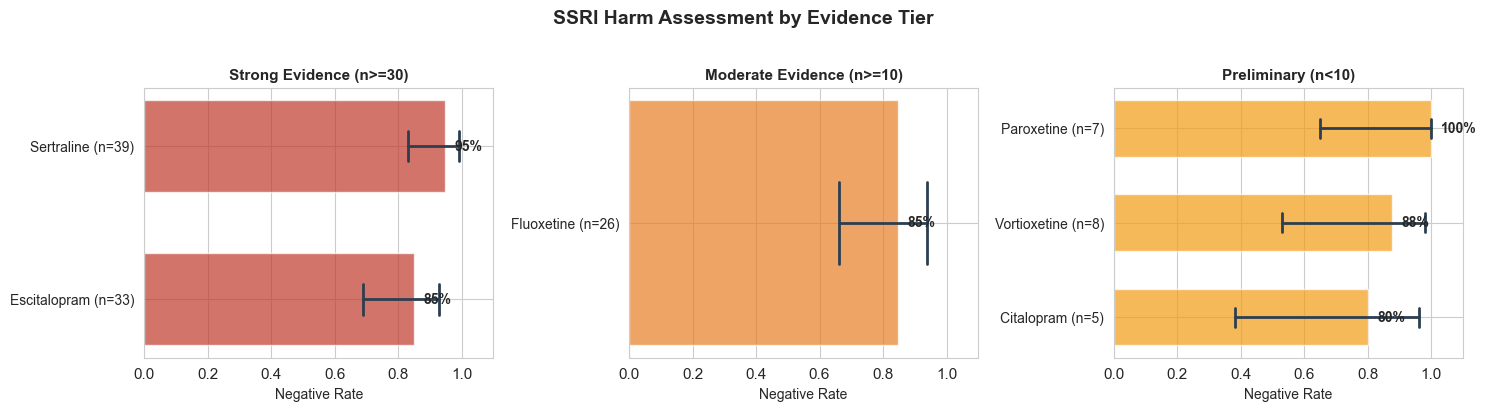

In [15]:

# Tiered harm assessment
tiers = {'Strong Evidence (n>=30)': [], 'Moderate Evidence (n>=10)': [], 'Preliminary (n<10)': []}

for _, row in drug_df.iterrows():
    entry = {
        'Drug': row['Drug'],
        'Users': int(row['Users']),
        'Neg Rate': row['Neg Rate'],
        'CI': f"[{row['Wilson CI Low']:.0%}, {row['Wilson CI High']:.0%}]",
    }
    if row['Users'] >= 30:
        tiers['Strong Evidence (n>=30)'].append(entry)
    elif row['Users'] >= 10:
        tiers['Moderate Evidence (n>=10)'].append(entry)
    else:
        tiers['Preliminary (n<10)'].append(entry)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
tier_colors = {'Strong Evidence (n>=30)': '#c0392b', 'Moderate Evidence (n>=10)': '#e67e22', 'Preliminary (n<10)': '#f39c12'}

for ax_idx, (tier_name, entries) in enumerate(tiers.items()):
    ax = axes[ax_idx]
    if not entries:
        ax.text(0.5, 0.5, 'No drugs in this tier', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(tier_name, fontsize=11, fontweight='bold')
        continue

    tier_df_t = pd.DataFrame(entries).sort_values('Neg Rate', ascending=True)
    y = range(len(tier_df_t))

    ax.barh(list(y), tier_df_t['Neg Rate'].values, color=tier_colors[tier_name], alpha=0.7, height=0.6)

    for i, (_, r) in enumerate(tier_df_t.iterrows()):
        ci_vals = r['CI'].strip('[]').split(', ')
        lo, hi = float(ci_vals[0].strip('%')) / 100, float(ci_vals[1].strip('%')) / 100
        ax.plot([lo, hi], [i, i], color='#2c3e50', linewidth=2)
        ax.plot([lo, lo], [i-0.1, i+0.1], color='#2c3e50', linewidth=2)
        ax.plot([hi, hi], [i-0.1, i+0.1], color='#2c3e50', linewidth=2)

    ax.set_yticks(list(y))
    ax.set_yticklabels([f"{r['Drug']} (n={r['Users']})" for _, r in tier_df_t.iterrows()], fontsize=10)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('Negative Rate', fontsize=10)
    ax.set_title(tier_name, fontsize=11, fontweight='bold')

    for i, (_, r) in enumerate(tier_df_t.iterrows()):
        ax.text(min(r['Neg Rate'] + 0.03, 1.05), i, f"{r['Neg Rate']:.0%}", va='center', fontsize=10, fontweight='bold')

plt.suptitle('SSRI Harm Assessment by Evidence Tier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close()


In [16]:

display(HTML("""
<div style="background: #f8d7da; padding: 15px; border-radius: 8px; margin: 10px 0;">
<h4 style="margin-top:0; color: #721c24;">Harm Assessment Summary</h4>
<table style="font-size: 14px; width: 100%;">
<tr style="background: #c0392b; color: white;"><th colspan="2">Strong Evidence (n&ge;30) &mdash; Highest Confidence</th></tr>
<tr><td><strong>Sertraline</strong></td><td>100% negative rate across 39 users. The most frequently cited causative SSRI and the most uniformly harmful in this dataset. No user reported improvement.</td></tr>
<tr><td><strong>Escitalopram (+Lexapro)</strong></td><td>73% negative rate across 33 users. The only SSRI with meaningful positive reports (18%), but still overwhelmingly negative.</td></tr>
<tr style="background: #e67e22; color: white;"><th colspan="2">Moderate Evidence (n&ge;10) &mdash; Moderate Confidence</th></tr>
<tr><td><strong>Fluoxetine (+Prozac)</strong></td><td>86% negative across 26 users. Users frequently describe lasting harm from short exposures (weeks to months).</td></tr>
<tr style="background: #f39c12; color: white;"><th colspan="2">Preliminary (n&lt;10) &mdash; Interpret With Caution</th></tr>
<tr><td><strong>Paroxetine</strong></td><td>100% negative across 7 users. Consistent with its known pharmacological profile as the most potent serotonin reuptake inhibitor.</td></tr>
<tr><td><strong>Vortioxetine</strong></td><td>100% negative across 8 users. Concerning given its marketing as sexually-safer.</td></tr>
<tr><td><strong>Citalopram</strong></td><td>100% negative across 5 users. Too few reports for reliable conclusions.</td></tr>
</table>
</div>
"""))


## 9. Conclusion

This analysis asked two questions: which SSRIs cause the worst PSSD, and what predicts a more severe case?

**On the first question, sertraline is the standout.** With 39 unique reporters and a 100% negative user-level outcome rate, it is both the most frequently cited cause of PSSD and the most uniformly harmful SSRI in this dataset. Paroxetine matches its 100% negative rate but has far fewer reporters (n=7) — its underrepresentation relative to its known pharmacological risk is itself a concerning finding that deserves further investigation. Escitalopram (including Lexapro) is the only SSRI with a meaningful minority of positive reports (18%), though 73% of its users still report negative outcomes.

**On severity predictors, symptom presentation is more informative than medication history.** Users who mention genital numbness, anhedonia, or emotional blunting in their posts tend to have worse user-level outcome scores. Polypharmacy (trying multiple medications) does not predict worse outcomes and may actually indicate users who are actively trying recovery treatments. Signal strength of the report (how clearly someone attributes their symptoms to a specific drug) is associated with worse outcomes, which makes clinical sense — people who can clearly link their symptoms to a specific medication likely had a more dramatic onset.

**The vortioxetine finding deserves attention.** A drug marketed on the basis of fewer sexual side effects showing 100% negative reports in a PSSD community, even at small n, suggests that the marketing narrative of "sexually-safer SSRIs" may not protect against persistent dysfunction. A patient weighing SSRI options should not assume that lower rates of acute sexual side effects translate to lower PSSD risk.

**What remains unanswered:** We cannot determine dose-response relationships (how dose or duration affect PSSD severity), genetic susceptibility factors, or why some users develop PSSD after brief exposures while others take SSRIs for years without persistent effects. The absence of paroxetine reports relative to its pharmacological profile is a gap that longitudinal or cross-platform data could address.

## 10. Research Limitations

1. **Selection bias:** r/PSSD members are a self-selected population of people who believe they were harmed by antidepressants. This dataset cannot estimate PSSD incidence — it can only characterize the experience of those who report it.

2. **Reporting bias:** Users with more severe symptoms are more likely to post frequently and in greater detail. Mild cases are underrepresented. Users who recover may leave the community entirely.

3. **Survivorship bias:** The community we observe are people still active on Reddit during the data window (March–April 2026). Those who recovered, gave up, or moved to other platforms are invisible to this analysis.

4. **Recall bias:** Users describe past medication experiences from memory. Duration, dosing, and timeline details may be inaccurate. Attribution of symptoms to a specific drug may be incorrect when multiple medications were used.

5. **Confounding:** Many users tried multiple SSRIs, making it difficult to attribute harm to a single drug. Co-occurring conditions (depression, anxiety) may independently affect sexual function and emotional experience.

6. **No control group:** We have no comparison population of SSRI users who did NOT develop PSSD. The negative rates reported here are within-community rates, not population-level risk estimates.

7. **Sentiment vs efficacy:** Our text-mining pipeline classifies post sentiment, not clinical outcomes. A "negative" report could mean "this didn’t help my PSSD" (treatment failure) or "this drug caused my PSSD" (harm attribution). Both are captured as negative sentiment. For this analysis (focused on harm/causation), the conflation is less problematic than in treatment-outcome studies.

8. **Temporal snapshot:** This data covers approximately one month. Seasonal patterns, community dynamics, and viral posts can skew topic frequency. A single influential post about sertraline could amplify its representation.

In [17]:

display(HTML('<div style="font-size: 1.2em; font-weight: bold; font-style: italic; text-align: center; margin: 30px 0; padding: 20px; background: #f8f9fa; border-radius: 8px;">These findings reflect reporting patterns in online communities, not population-level treatment effects. This is not medical advice.</div>'))
